### Threshold Testing and Evaluation

This notebook evaluates all 30 model-configuration combinations using cosine similarity and threshold-based binary classification. 

Part 1 runs the full evaluation on all 154 pairs and identifies the optimal threshold for each combination. 

Part 2 validates the main findings using a stratified 80/20 split 
where the threshold is selected on the training portion and final metrics are reported on a held-out test set that never influenced threshold selection.

### Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                             accuracy_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split

# Paths
base = r"C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final"
data_path = os.path.join(base, "data", "processed", "dataset_preprocessed.csv")
embeddings_dir = os.path.join(base, "data", "embeddings")
results_dir = os.path.join(base, "data", "results")
figures_dir = os.path.join(base, "figures", "main")

os.makedirs(results_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

# Load dataset
df = pd.read_csv(data_path)
labels = df['similarity_label'].values

print("Libraries loaded successfully")
print(f"Dataset loaded: {df.shape}")
print(f"Labels: {np.unique(labels, return_counts=True)}")
print(f"Results will be saved to: {results_dir}")
print(f"Figures will be saved to: {figures_dir}")

Libraries loaded successfully
Dataset loaded: (154, 33)
Labels: (array([0, 1]), array([77, 77]))
Results will be saved to: C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final\data\results
Figures will be saved to: C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final\figures\main


### Models, Configurations, and Threshold Sweep

For each model-configuration combination, cosine similarity scores are computed row-wise between Finnish and English embeddings. 

A threshold sweep tests 101 values from 0.00 to 1.00 in steps of 0.01. At each threshold, pairs with a similarity score above the threshold are classified as equivalent. 

Precision, recall, F1, and accuracy are recorded at every step.

In [2]:
model_keys = ['mpnet', 'stsb', 'e5', 'labse', 'finbert']
configs = [1, 2, 3, 4, 5, 6]
thresholds = np.round(np.arange(0.00, 1.01, 0.01), 2)

def threshold_sweep(fi_emb, en_emb, labels, thresholds):
    similarity_scores = np.sum(fi_emb * en_emb, axis=1)

    results = []
    for threshold in thresholds:
        preds = (similarity_scores >= threshold).astype(int)
        precision = precision_score(labels, preds, zero_division=0)
        recall = recall_score(labels, preds, zero_division=0)
        f1 = f1_score(labels, preds, zero_division=0)
        accuracy = accuracy_score(labels, preds)
        results.append({
            'threshold': threshold,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'accuracy': accuracy
        })

    sweep_df = pd.DataFrame(results)
    auc = roc_auc_score(labels, similarity_scores)
    fpr, tpr, roc_thresholds = roc_curve(labels, similarity_scores)

    return sweep_df, similarity_scores, auc, fpr, tpr

print(f"Models: {model_keys}")
print(f"Configurations: {configs}")
print(f"Thresholds: {len(thresholds)} values from {thresholds[0]} to {thresholds[-1]}")
print("AUC-ROC computation included.")

Models: ['mpnet', 'stsb', 'e5', 'labse', 'finbert']
Configurations: [1, 2, 3, 4, 5, 6]
Thresholds: 101 values from 0.0 to 1.0
AUC-ROC computation included.


### Part 1: Full Dataset Evaluation

All 30 model-configuration combinations are evaluated here. For each combination, Finnish and English embeddings are loaded, cosine similarity is computed row-wise, and the threshold sweep identifies the optimal threshold that maximises F1. 

AUC is computed directly from the raw similarity scores, independent of any threshold. 

Results are saved as individual CSV files for each combination and collected into a single summary table.

In [3]:
summary_rows = []
all_sweep_results = {}
all_similarity_scores = {}
all_auc = {}
all_fpr_tpr = {}

config_names = {
    1: 'Outcomes (Raw)',
    2: 'Outcomes + Contents (Raw)',
    3: 'Outcomes + Contents + Assessment (Raw)',
    4: 'Outcomes (Lemmatized)',
    5: 'Outcomes + Contents (Lemmatized)',
    6: 'Outcomes + Contents + Assessment (Lemmatized)'
}

for model_key in model_keys:
    for config_num in configs:
        fi_path = os.path.join(embeddings_dir, f'{model_key}_config{config_num}_fi.npy')
        en_path = os.path.join(embeddings_dir, f'{model_key}_config{config_num}_en.npy')
        fi_emb = np.load(fi_path)
        en_emb = np.load(en_path)
        
        sweep_df, sim_scores, auc, fpr, tpr = threshold_sweep(fi_emb, en_emb, labels, thresholds)
        
        key = f'{model_key}_config{config_num}'
        all_sweep_results[key] = sweep_df
        all_similarity_scores[key] = sim_scores
        all_auc[key] = auc
        all_fpr_tpr[key] = (fpr, tpr)
        
        best_idx = sweep_df['f1'].idxmax()
        best_row = sweep_df.loc[best_idx]
        
        csv_path = os.path.join(results_dir, f'threshold_{model_key}_config{config_num}.csv')
        sweep_df.to_csv(csv_path, index=False)
        
        summary_rows.append({
            'model': model_key,
            'config': config_names[config_num],
            'best_threshold': best_row['threshold'],
            'precision': round(best_row['precision'], 4),
            'recall': round(best_row['recall'], 4),
            'f1': round(best_row['f1'], 4),
            'accuracy': round(best_row['accuracy'], 4),
            'auc': round(auc, 4)
        })

summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(results_dir, 'full_evaluation_summary.csv')
summary_df.to_csv(summary_path, index=False)

print(f"All 30 combinations evaluated. Summary saved.\n")
display(summary_df)

All 30 combinations evaluated. Summary saved.



,model,config,best_threshold,precision,recall,f1,accuracy,auc
0,mpnet,Outcomes (Raw),0.76,0.9157,0.9870,0.9500,0.9481,0.9845
1,mpnet,Outcomes + Contents (Raw),0.80,0.9605,0.9481,0.9542,0.9545,0.9845
2,mpnet,Outcomes + Contents + Assessment (Raw),0.80,0.9605,0.9481,0.9542,0.9545,0.9845
3,mpnet,Outcomes (Lemmatized),0.70,0.8750,1.0000,0.9333,0.9286,0.9825
4,mpnet,Outcomes + Contents (Lemmatized),0.70,0.8750,1.0000,0.9333,0.9286,0.9825
5,mpnet,Outcomes + Contents + Assessment (Lemmatized),0.70,0.8750,1.0000,0.9333,0.9286,0.9825
6,stsb,Outcomes (Raw),0.89,0.9167,1.0000,0.9565,0.9545,0.9958
7,stsb,Outcomes + Contents (Raw),0.92,0.9863,0.9351,0.9600,0.9610,0.9958
8,stsb,Outcomes + Contents + Assessment (Raw),0.92,0.9863,0.9351,0.9600,0.9610,0.9958
9,stsb,Outcomes (Lemmatized),0.89,0.9487,0.9610,0.9548,0.9545,0.9885


### Model 1: paraphrase-multilingual-mpnet-base-v2

This model was developed by Reimers and Gurevych (2020) as part of the multilingual extension of Sentence-BERT. 

It was trained using multilingual knowledge distillation, where a strong English teacher model transfers semantic similarity knowledge to a multilingual student model supporting over 50 languages including Finnish. 

The model uses an MPNet backbone and produces 768-dimensional sentence embeddings. 

It is one of the most widely used multilingual sentence embedding models and serves as a strong general-purpose baseline in this evaluation.

#### Results: paraphrase-multilingual-mpnet-base-v2

In [4]:
mpnet_results = summary_df[summary_df['model'] == 'mpnet'].reset_index(drop=True)
display(mpnet_results[['config', 'best_threshold', 'precision', 'recall', 'f1', 'accuracy', 'auc']])

,config,best_threshold,precision,recall,f1,accuracy,auc
0,Outcomes (Raw),0.76,0.9157,0.9870,0.9500,0.9481,0.9845
1,Outcomes + Contents (Raw),0.80,0.9605,0.9481,0.9542,0.9545,0.9845
2,Outcomes + Contents + Assessment (Raw),0.80,0.9605,0.9481,0.9542,0.9545,0.9845
3,Outcomes (Lemmatized),0.70,0.8750,1.0000,0.9333,0.9286,0.9825
4,Outcomes + Contents (Lemmatized),0.70,0.8750,1.0000,0.9333,0.9286,0.9825
5,Outcomes + Contents + Assessment (Lemmatized),0.70,0.8750,1.0000,0.9333,0.9286,0.9825


### Visualisations: paraphrase-multilingual-mpnet-base-v2

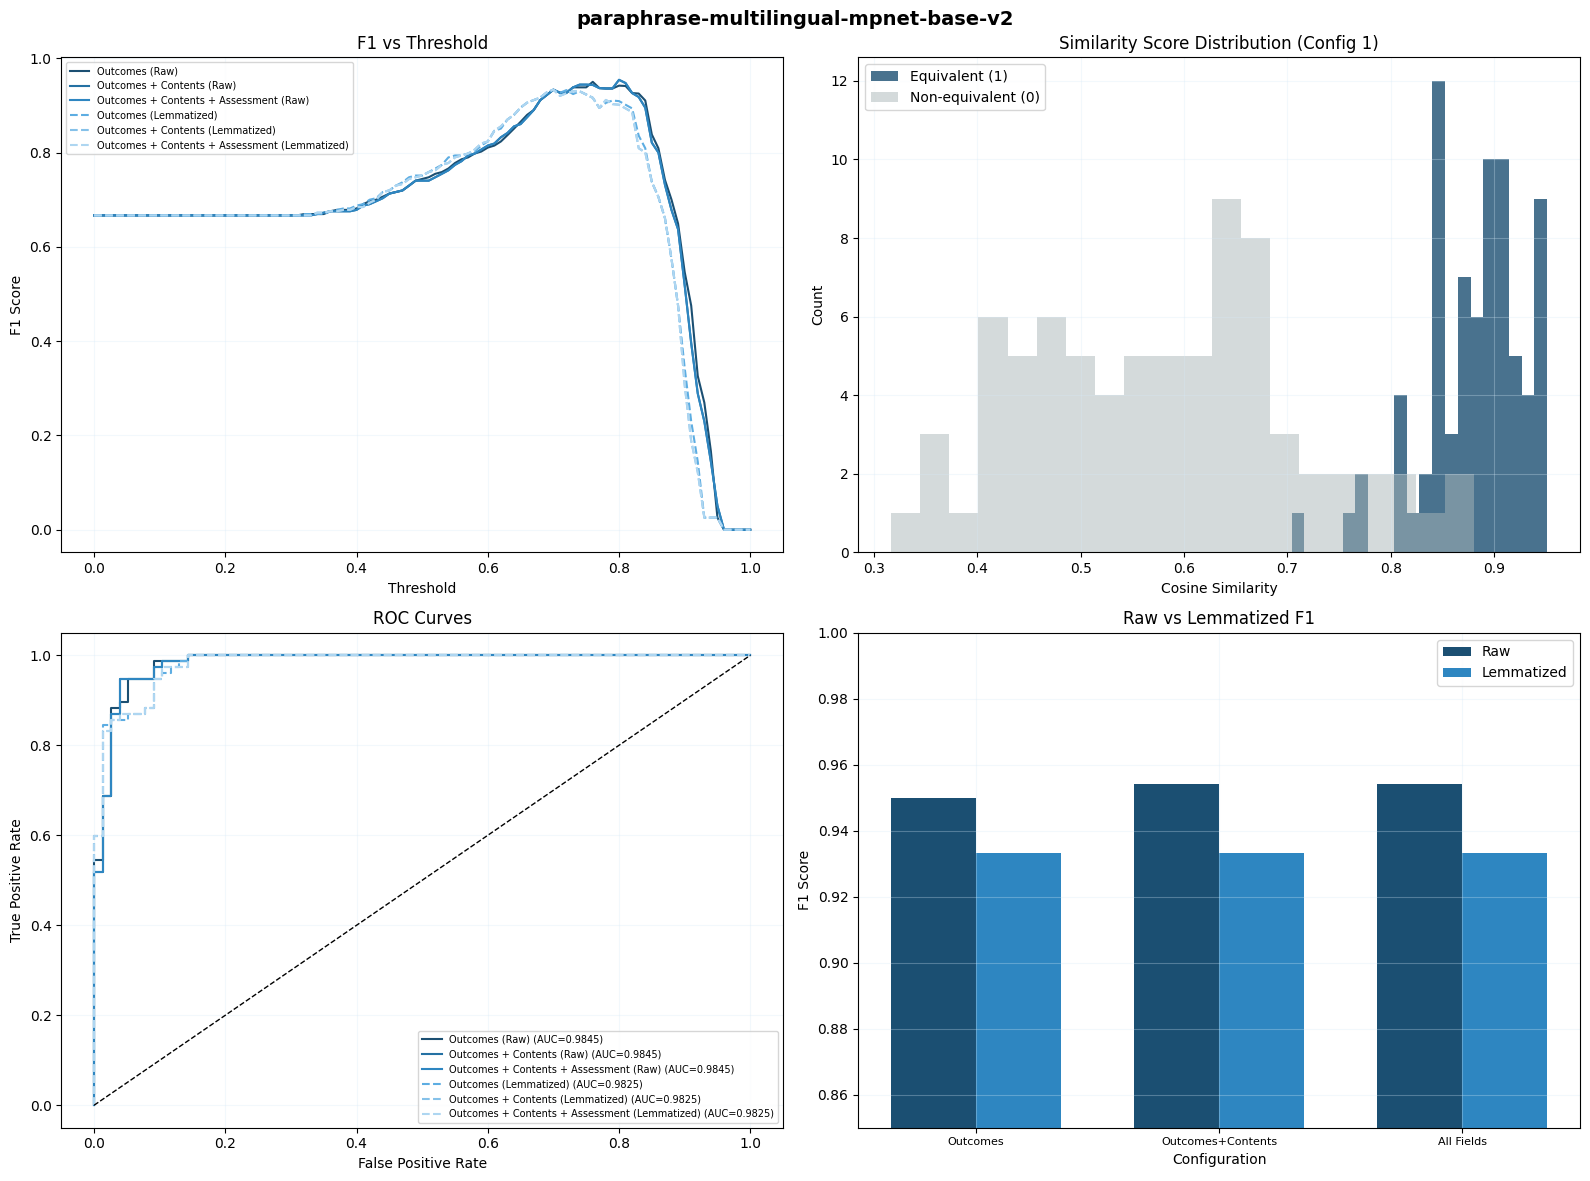

Plot saved: C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final\figures\main\mpnet_visualisations.png


In [5]:
# Color theme
PRIMARY = '#1B4F72'
SECONDARY = '#2E86C1'
POSITIVE = '#1B4F72'
NEGATIVE = '#AAB7B8'
GRID_COLOR = '#D6EAF8'

# Six config colors with varied shades and linestyles
colors = ['#1B4F72', '#2471A3', '#2E86C1', '#5DADE2', '#85C1E9', '#AED6F1']
linestyles = ['-', '-', '-', '--', '--', '--']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('paraphrase-multilingual-mpnet-base-v2', fontsize=14, fontweight='bold')

# Plot 1: F1 vs Threshold
ax1 = axes[0, 0]
for i, config_num in enumerate(configs):
    key = f'mpnet_config{config_num}'
    sweep = all_sweep_results[key]
    ax1.plot(sweep['threshold'], sweep['f1'], color=colors[i],
             linestyle=linestyles[i], label=config_names[config_num], linewidth=1.5)
ax1.set_title('F1 vs Threshold')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('F1 Score')
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3, color=GRID_COLOR)

# Plot 2: Similarity Score Distribution (Config 1)
ax2 = axes[0, 1]
key = 'mpnet_config1'
scores = all_similarity_scores[key]
pos_scores = scores[labels == 1]
neg_scores = scores[labels == 0]
ax2.hist(pos_scores, bins=20, alpha=0.8, color=POSITIVE, label='Equivalent (1)')
ax2.hist(neg_scores, bins=20, alpha=0.5, color=NEGATIVE, label='Non-equivalent (0)')
ax2.set_title('Similarity Score Distribution (Config 1)')
ax2.set_xlabel('Cosine Similarity')
ax2.set_ylabel('Count')
ax2.legend()
ax2.grid(True, alpha=0.3, color=GRID_COLOR)

# Plot 3: ROC Curves
ax3 = axes[1, 0]
for i, config_num in enumerate(configs):
    key = f'mpnet_config{config_num}'
    fpr, tpr = all_fpr_tpr[key]
    auc_val = all_auc[key]
    ax3.plot(fpr, tpr, color=colors[i], linestyle=linestyles[i], linewidth=1.5,
             label=f'{config_names[config_num]} (AUC={auc_val:.4f})')
ax3.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax3.set_title('ROC Curves')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend(fontsize=7)
ax3.grid(True, alpha=0.3, color=GRID_COLOR)

# Plot 4: Raw vs Lemmatized F1
ax4 = axes[1, 1]
raw_f1 = [summary_df[(summary_df['model'] == 'mpnet') &
          (summary_df['config'] == config_names[i])]['f1'].values[0] for i in [1, 2, 3]]
lem_f1 = [summary_df[(summary_df['model'] == 'mpnet') &
          (summary_df['config'] == config_names[i])]['f1'].values[0] for i in [4, 5, 6]]
x = np.arange(3)
width = 0.35
ax4.bar(x - width/2, raw_f1, width, label='Raw', color=PRIMARY)
ax4.bar(x + width/2, lem_f1, width, label='Lemmatized', color=SECONDARY)
ax4.set_title('Raw vs Lemmatized F1')
ax4.set_xlabel('Configuration')
ax4.set_ylabel('F1 Score')
ax4.set_xticks(x)
ax4.set_xticklabels(['Outcomes', 'Outcomes+Contents', 'All Fields'], fontsize=8)
ax4.legend()
ax4.set_ylim(0.85, 1.0)
ax4.grid(True, alpha=0.3, color=GRID_COLOR)

plt.tight_layout()
plot_path = os.path.join(figures_dir, 'mpnet_visualisations.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

The model performs consistently well across all six configurations, with F1 scores ranging from 0.9333 to 0.9542 and AUC values tightly clustered between 0.9825 and 0.9845. 

The F1 vs threshold curves show that all configurations peak in the same narrow range between 0.76 and 0.80, indicating stable and predictable threshold behaviour regardless of which fields are included. 

The similarity score distribution shows reasonable separation between equivalent and non-equivalent pairs, though some overlap remains in the 0.6 to 0.8 cosine similarity range, which explains why the model occasionally misclassifies hard negative pairs from the same subject domain. 

Raw configurations consistently outperform their lemmatized counterparts, suggesting that lemmatization does not help this model and may slightly reduce the richness of the input representations. 

Adding contents and assessment fields beyond outcomes produces marginal improvement on raw text but no benefit on lemmatized text.

### Model 2: stsb-xlm-r-multilingual

This model is based on the XLM-RoBERTa architecture developed by Conneau et al. (2020) and fine-tuned on semantic textual similarity tasks using multilingual training data. 

XLM-RoBERTa was pre-trained on 2.5 terabytes of filtered CommonCrawl data covering 100 languages including Finnish, giving it a strong cross-lingual foundation. 

The stsb fine-tuning step explicitly optimises the model for sentence similarity tasks, making it a natural candidate for course description comparison. 

Like mpnet, it produces 768-dimensional sentence embeddings through the sentence-transformers library.

### Results: stsb-xlm-r-multilingual

In [6]:
stsb_results = summary_df[summary_df['model'] == 'stsb'].reset_index(drop=True)
display(stsb_results[['config', 'best_threshold', 'precision', 'recall', 'f1', 'accuracy', 'auc']])

,config,best_threshold,precision,recall,f1,accuracy,auc
0,Outcomes (Raw),0.89,0.9167,1.0000,0.9565,0.9545,0.9958
1,Outcomes + Contents (Raw),0.92,0.9863,0.9351,0.9600,0.9610,0.9958
2,Outcomes + Contents + Assessment (Raw),0.92,0.9863,0.9351,0.9600,0.9610,0.9958
3,Outcomes (Lemmatized),0.89,0.9487,0.9610,0.9548,0.9545,0.9885
4,Outcomes + Contents (Lemmatized),0.89,0.9494,0.9740,0.9615,0.9610,0.9907
5,Outcomes + Contents + Assessment (Lemmatized),0.89,0.9494,0.9740,0.9615,0.9610,0.9907


### Visualisations: stsb-xlm-r-multilingual

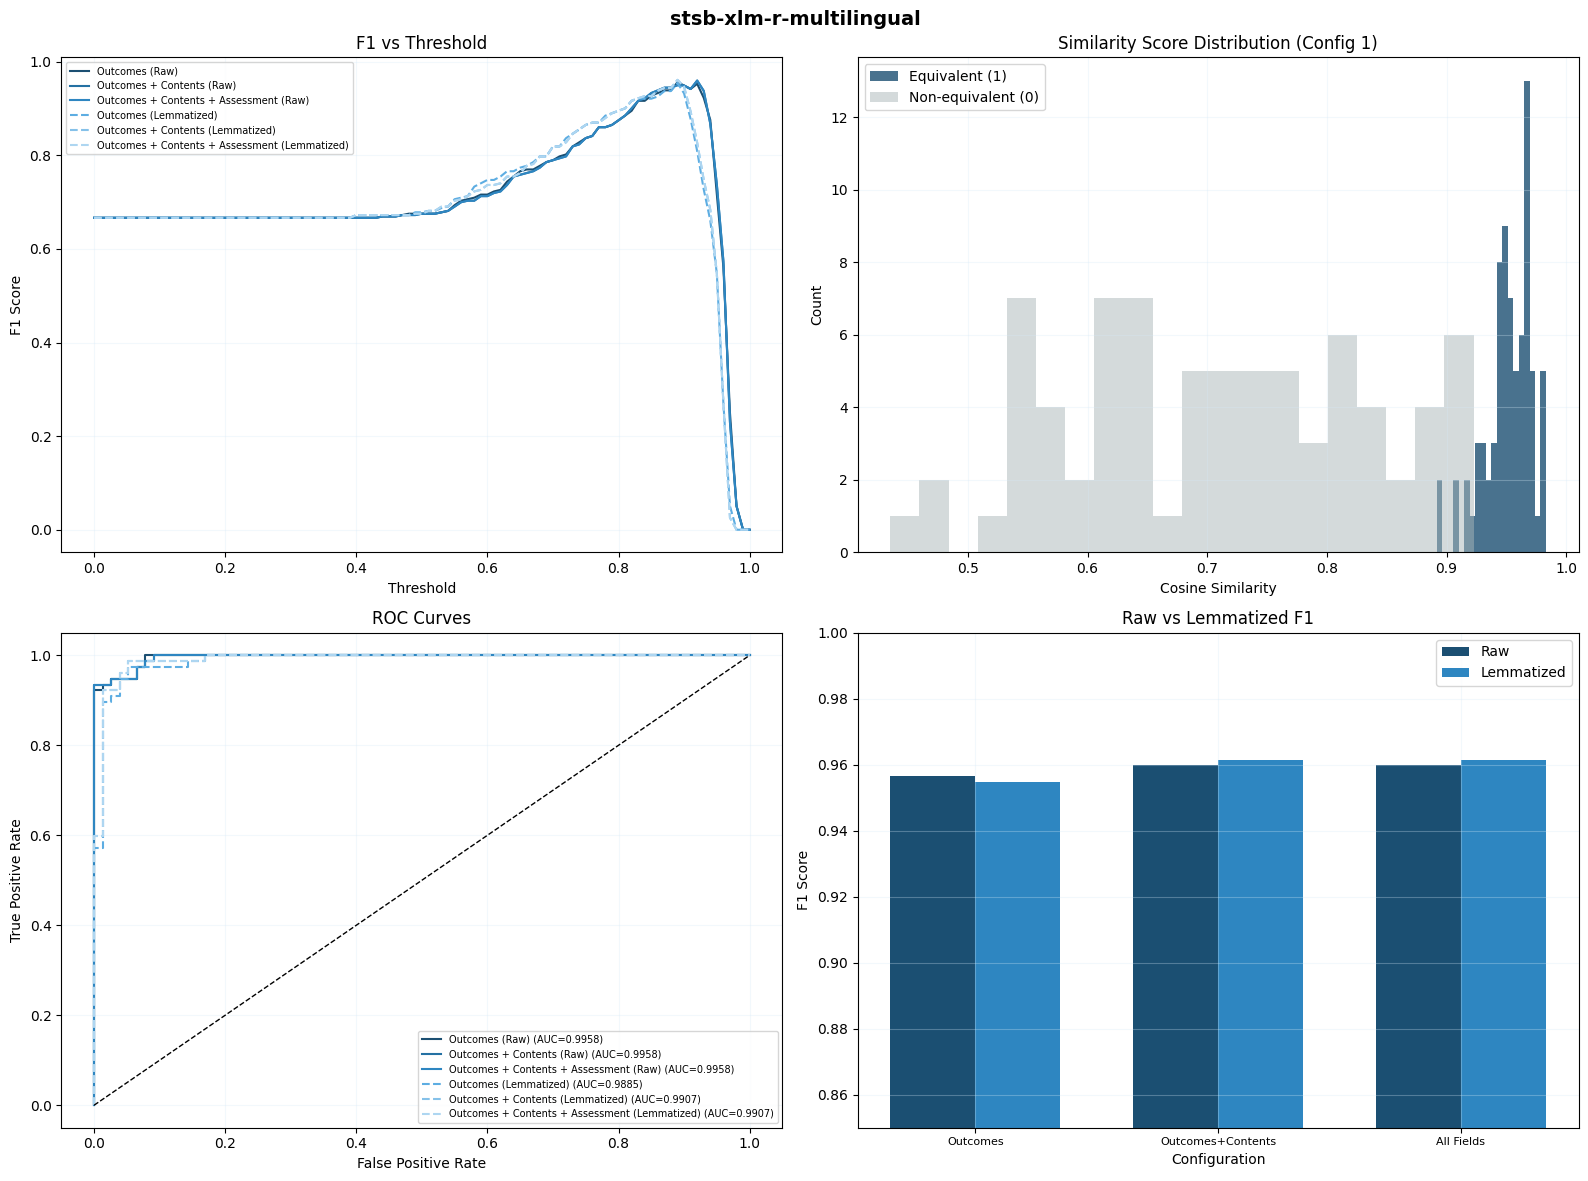

Plot saved: C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final\figures\main\stsb_visualisations.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('stsb-xlm-r-multilingual', fontsize=14, fontweight='bold')

# Plot 1: F1 vs Threshold
ax1 = axes[0, 0]
for i, config_num in enumerate(configs):
    key = f'stsb_config{config_num}'
    sweep = all_sweep_results[key]
    ax1.plot(sweep['threshold'], sweep['f1'], color=colors[i],
             linestyle=linestyles[i], label=config_names[config_num], linewidth=1.5)
ax1.set_title('F1 vs Threshold')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('F1 Score')
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3, color=GRID_COLOR)

# Plot 2: Similarity Score Distribution (Config 1)
ax2 = axes[0, 1]
key = 'stsb_config1'
scores = all_similarity_scores[key]
pos_scores = scores[labels == 1]
neg_scores = scores[labels == 0]
ax2.hist(pos_scores, bins=20, alpha=0.8, color=POSITIVE, label='Equivalent (1)')
ax2.hist(neg_scores, bins=20, alpha=0.5, color=NEGATIVE, label='Non-equivalent (0)')
ax2.set_title('Similarity Score Distribution (Config 1)')
ax2.set_xlabel('Cosine Similarity')
ax2.set_ylabel('Count')
ax2.legend()
ax2.grid(True, alpha=0.3, color=GRID_COLOR)

# Plot 3: ROC Curves
ax3 = axes[1, 0]
for i, config_num in enumerate(configs):
    key = f'stsb_config{config_num}'
    fpr, tpr = all_fpr_tpr[key]
    auc_val = all_auc[key]
    ax3.plot(fpr, tpr, color=colors[i], linestyle=linestyles[i], linewidth=1.5,
             label=f'{config_names[config_num]} (AUC={auc_val:.4f})')
ax3.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax3.set_title('ROC Curves')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend(fontsize=7)
ax3.grid(True, alpha=0.3, color=GRID_COLOR)

# Plot 4: Raw vs Lemmatized F1
ax4 = axes[1, 1]
raw_f1 = [summary_df[(summary_df['model'] == 'stsb') &
          (summary_df['config'] == config_names[i])]['f1'].values[0] for i in [1, 2, 3]]
lem_f1 = [summary_df[(summary_df['model'] == 'stsb') &
          (summary_df['config'] == config_names[i])]['f1'].values[0] for i in [4, 5, 6]]
x = np.arange(3)
width = 0.35
ax4.bar(x - width/2, raw_f1, width, label='Raw', color=PRIMARY)
ax4.bar(x + width/2, lem_f1, width, label='Lemmatized', color=SECONDARY)
ax4.set_title('Raw vs Lemmatized F1')
ax4.set_xlabel('Configuration')
ax4.set_ylabel('F1 Score')
ax4.set_xticks(x)
ax4.set_xticklabels(['Outcomes', 'Outcomes+Contents', 'All Fields'], fontsize=8)
ax4.legend()
ax4.set_ylim(0.85, 1.0)
ax4.grid(True, alpha=0.3, color=GRID_COLOR)

plt.tight_layout()
plot_path = os.path.join(figures_dir, 'stsb_visualisations.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

The stsb model delivers strong and consistent performance across all six configurations, with F1 scores ranging from 0.9548 to 0.9615 and AUC values between 0.9885 and 0.9958. 

Compared to mpnet, the similarity score distribution shows cleaner separation between equivalent and non-equivalent pairs, with non-equivalent pairs concentrated below 0.85 and equivalent pairs clustered tightly above 0.90. 

This tighter separation is reflected in the higher optimal thresholds between 0.89 and 0.92, meaning the model is more confident and decisive in its similarity assignments. 

Unlike mpnet, lemmatization produces marginal improvement on the outcomes-only configuration and near-identical results on longer configurations, suggesting that the stsb model is slightly more 
tolerant of morphological variation than mpnet. 

The ROC curves for all six configurations sit close together near the top left corner, confirming that the model performs reliably regardless of which text fields are included.

### Model 3: intfloat/multilingual-e5-base

The multilingual E5 model was developed by Wang et al. (2024) and trained using weakly supervised contrastive learning on a large collection of multilingual text pairs. 

E5 stands for EmbEddings from bidirEctional Encoder Epresentations, and the base variant uses an XLM-RoBERTa backbone fine-tuned specifically for dense retrieval and semantic similarity tasks. 

A key design feature of this model is its use of task prefixes during inference: inputs intended as documents to be compared are prepended with "passage: " to signal the encoding mode. 

In this study, both Finnish and English course descriptions receive the "passage: " prefix symmetrically, reflecting the document-to-document nature of the comparison task.

### Results: intfloat/multilingual-e5-base

In [8]:
e5_results = summary_df[summary_df['model'] == 'e5'].reset_index(drop=True)
display(e5_results[['config', 'best_threshold', 'precision', 'recall', 'f1', 'accuracy', 'auc']])

,config,best_threshold,precision,recall,f1,accuracy,auc
0,Outcomes (Raw),0.86,0.8022,0.9481,0.8690,0.8571,0.9418
1,Outcomes + Contents (Raw),0.87,0.8523,0.9740,0.9091,0.9026,0.9659
2,Outcomes + Contents + Assessment (Raw),0.86,0.8409,0.9610,0.8970,0.8896,0.9448
3,Outcomes (Lemmatized),0.87,0.8875,0.9221,0.9045,0.9026,0.9558
4,Outcomes + Contents (Lemmatized),0.87,0.8810,0.9610,0.9193,0.9156,0.9713
5,Outcomes + Contents + Assessment (Lemmatized),0.87,0.8987,0.9221,0.9103,0.9091,0.9572


### Visualisations: intfloat/multilingual-e5-base

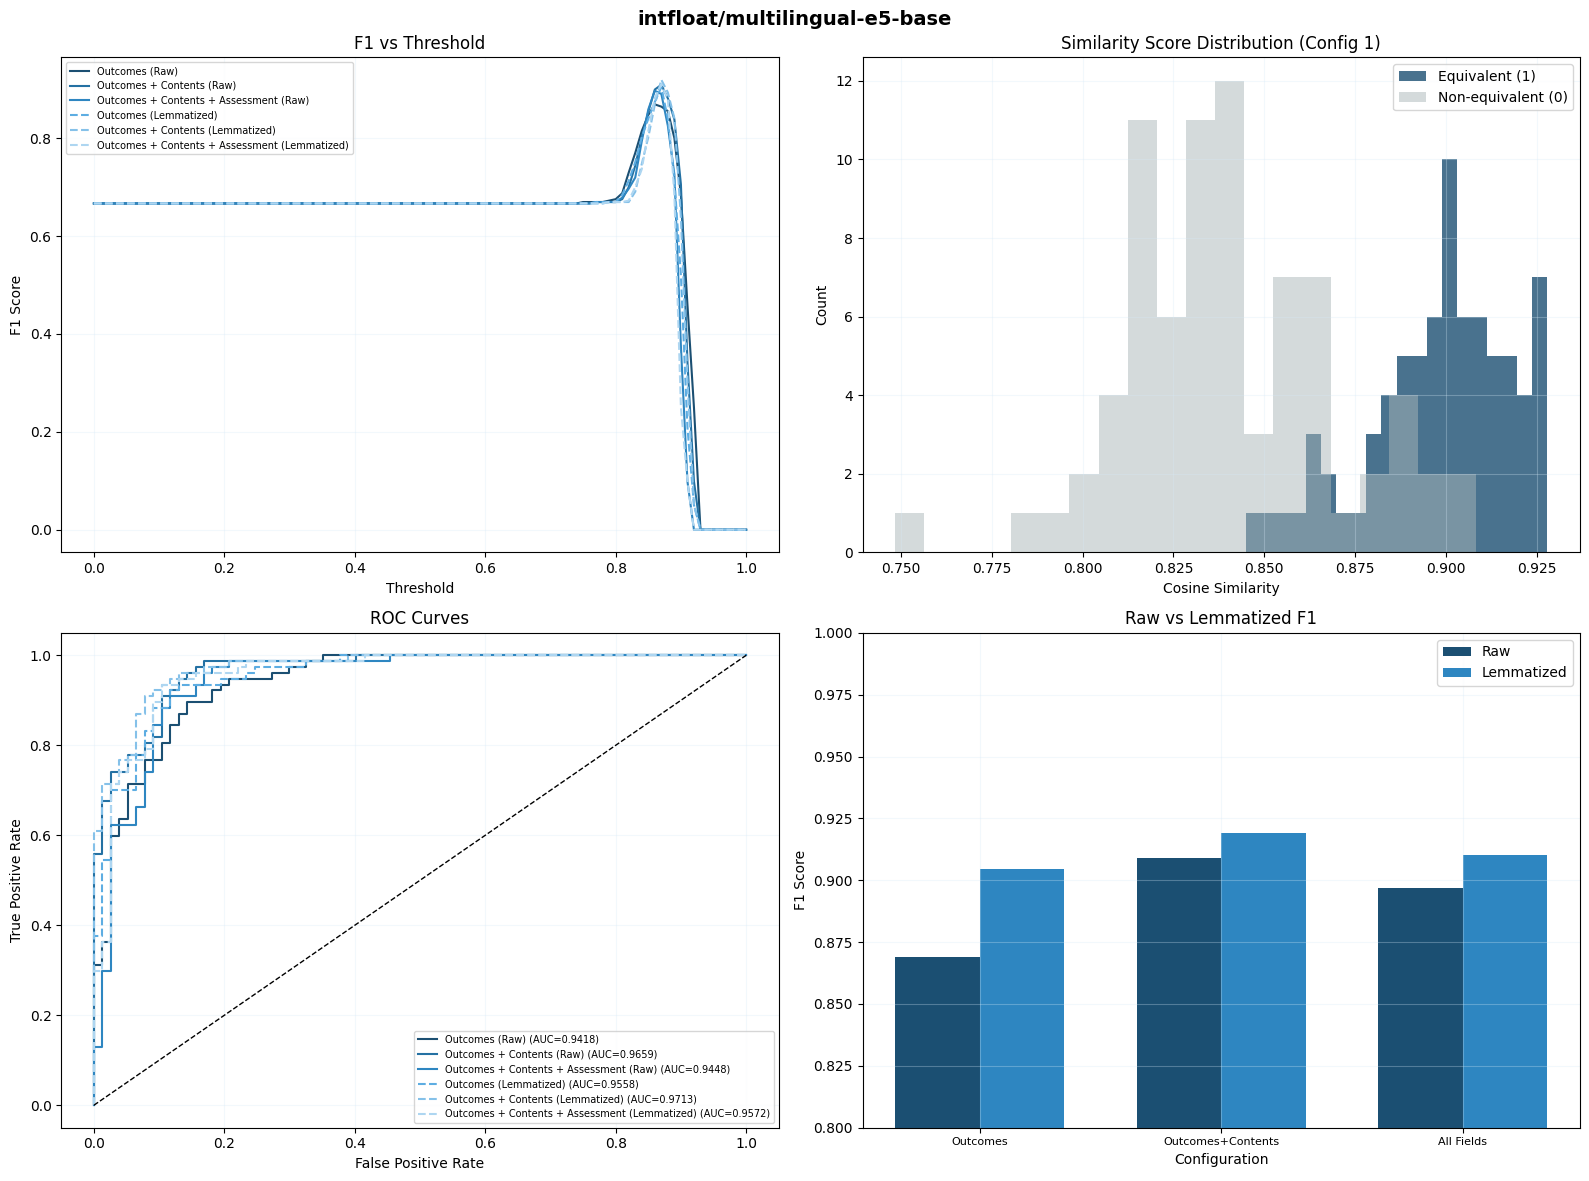

Plot saved: C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final\figures\main\e5_visualisations.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('intfloat/multilingual-e5-base', fontsize=14, fontweight='bold')

# Plot 1: F1 vs Threshold
ax1 = axes[0, 0]
for i, config_num in enumerate(configs):
    key = f'e5_config{config_num}'
    sweep = all_sweep_results[key]
    ax1.plot(sweep['threshold'], sweep['f1'], color=colors[i],
             linestyle=linestyles[i], label=config_names[config_num], linewidth=1.5)
ax1.set_title('F1 vs Threshold')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('F1 Score')
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3, color=GRID_COLOR)

# Plot 2: Similarity Score Distribution (Config 1)
ax2 = axes[0, 1]
key = 'e5_config1'
scores = all_similarity_scores[key]
pos_scores = scores[labels == 1]
neg_scores = scores[labels == 0]
ax2.hist(pos_scores, bins=20, alpha=0.8, color=POSITIVE, label='Equivalent (1)')
ax2.hist(neg_scores, bins=20, alpha=0.5, color=NEGATIVE, label='Non-equivalent (0)')
ax2.set_title('Similarity Score Distribution (Config 1)')
ax2.set_xlabel('Cosine Similarity')
ax2.set_ylabel('Count')
ax2.legend()
ax2.grid(True, alpha=0.3, color=GRID_COLOR)

# Plot 3: ROC Curves
ax3 = axes[1, 0]
for i, config_num in enumerate(configs):
    key = f'e5_config{config_num}'
    fpr, tpr = all_fpr_tpr[key]
    auc_val = all_auc[key]
    ax3.plot(fpr, tpr, color=colors[i], linestyle=linestyles[i], linewidth=1.5,
             label=f'{config_names[config_num]} (AUC={auc_val:.4f})')
ax3.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax3.set_title('ROC Curves')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend(fontsize=7)
ax3.grid(True, alpha=0.3, color=GRID_COLOR)

# Plot 4: Raw vs Lemmatized F1
ax4 = axes[1, 1]
raw_f1 = [summary_df[(summary_df['model'] == 'e5') &
          (summary_df['config'] == config_names[i])]['f1'].values[0] for i in [1, 2, 3]]
lem_f1 = [summary_df[(summary_df['model'] == 'e5') &
          (summary_df['config'] == config_names[i])]['f1'].values[0] for i in [4, 5, 6]]
x = np.arange(3)
width = 0.35
ax4.bar(x - width/2, raw_f1, width, label='Raw', color=PRIMARY)
ax4.bar(x + width/2, lem_f1, width, label='Lemmatized', color=SECONDARY)
ax4.set_title('Raw vs Lemmatized F1')
ax4.set_xlabel('Configuration')
ax4.set_ylabel('F1 Score')
ax4.set_xticks(x)
ax4.set_xticklabels(['Outcomes', 'Outcomes+Contents', 'All Fields'], fontsize=8)
ax4.legend()
ax4.set_ylim(0.80, 1.0)
ax4.grid(True, alpha=0.3, color=GRID_COLOR)

plt.tight_layout()
plot_path = os.path.join(figures_dir, 'e5_visualisations.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

The e5 model produces the narrowest F1 vs threshold curve of all models evaluated so far, with a sharp and unstable peak that drops steeply on both sides. 

This indicates that e5 is highly sensitive to threshold selection, meaning small changes in the chosen threshold produce large changes in performance. 

The similarity score distribution explains why: both equivalent and non-equivalent pairs are compressed into a very narrow cosine similarity range between 0.75 and 0.93, leaving little margin between the two classes. 

This compression is a known characteristic of the e5 model architecture and makes it less suitable for threshold-based classification compared to models that produce wider score distributions. 

Notably, e5 is the only model where lemmatization consistently improves performance across all three field combinations, suggesting that reducing Finnish morphological variation helps this model more than the others. 

The best F1 of 0.9193 is achieved on the lemmatized outcomes plus contents configuration, but this still falls below the performance 
of both mpnet and stsb on their best configurations.

### Model 4: sentence-transformers/LaBSE

LaBSE, which stands for Language-Agnostic BERT Sentence Embedding, was developed by Feng et al. (2022) and trained on 109 languages using a combination of masked language modelling and translation ranking objectives.

Unlike the other multilingual models in this study which were adapted from monolingual English models through knowledge distillation, LaBSE was trained from scratch with cross-lingual alignment as its primary objective.

This makes it architecturally distinct and particularly well suited for tasks where meaning must be matched across typologically different languages. 

Finnish and English differ substantially in morphology, word order flexibility, and vocabulary structure, making LaBSE a strong candidate for this evaluation. 

It was added to the study after an exploratory comparison showed it outperforming all four initially selected models.

### Results: sentence-transformers/LaBSE

In [10]:
labse_results = summary_df[summary_df['model'] == 'labse'].reset_index(drop=True)
display(labse_results[['config', 'best_threshold', 'precision', 'recall', 'f1', 'accuracy', 'auc']])

,config,best_threshold,precision,recall,f1,accuracy,auc
0,Outcomes (Raw),0.87,0.9625,1.000,0.9809,0.9805,0.9988
1,Outcomes + Contents (Raw),0.88,1.0000,0.961,0.9801,0.9805,0.9983
2,Outcomes + Contents + Assessment (Raw),0.84,0.9506,1.000,0.9747,0.9740,0.9968
3,Outcomes (Lemmatized),0.86,0.9506,1.000,0.9747,0.9740,0.9968
4,Outcomes + Contents (Lemmatized),0.87,0.9625,1.000,0.9809,0.9805,0.9983
5,Outcomes + Contents + Assessment (Lemmatized),0.86,0.9625,1.000,0.9809,0.9805,0.9971


### Visualisations: sentence-transformers/LaBSE

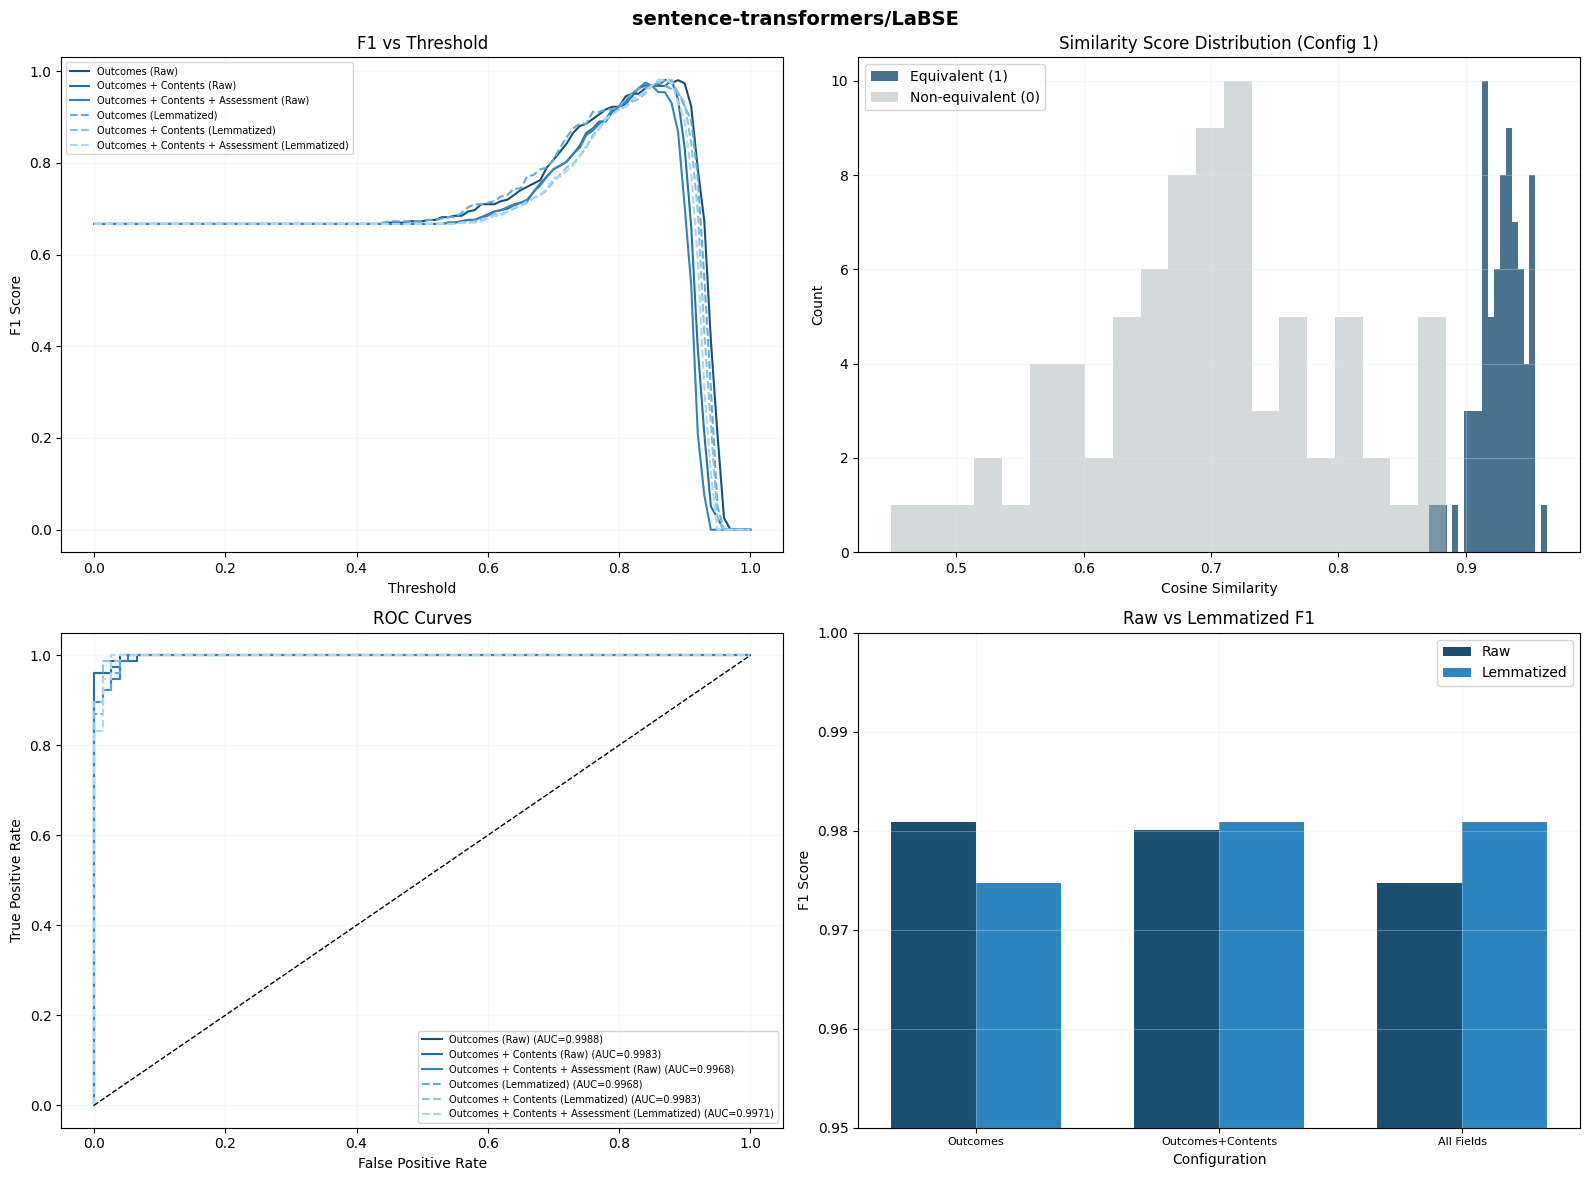

Plot saved: C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final\figures\main\labse_visualisations.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('sentence-transformers/LaBSE', fontsize=14, fontweight='bold')

# Plot 1: F1 vs Threshold
ax1 = axes[0, 0]
for i, config_num in enumerate(configs):
    key = f'labse_config{config_num}'
    sweep = all_sweep_results[key]
    ax1.plot(sweep['threshold'], sweep['f1'], color=colors[i],
             linestyle=linestyles[i], label=config_names[config_num], linewidth=1.5)
ax1.set_title('F1 vs Threshold')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('F1 Score')
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3, color=GRID_COLOR)

# Plot 2: Similarity Score Distribution (Config 1)
ax2 = axes[0, 1]
key = 'labse_config1'
scores = all_similarity_scores[key]
pos_scores = scores[labels == 1]
neg_scores = scores[labels == 0]
ax2.hist(pos_scores, bins=20, alpha=0.8, color=POSITIVE, label='Equivalent (1)')
ax2.hist(neg_scores, bins=20, alpha=0.5, color=NEGATIVE, label='Non-equivalent (0)')
ax2.set_title('Similarity Score Distribution (Config 1)')
ax2.set_xlabel('Cosine Similarity')
ax2.set_ylabel('Count')
ax2.legend()
ax2.grid(True, alpha=0.3, color=GRID_COLOR)

# Plot 3: ROC Curves
ax3 = axes[1, 0]
for i, config_num in enumerate(configs):
    key = f'labse_config{config_num}'
    fpr, tpr = all_fpr_tpr[key]
    auc_val = all_auc[key]
    ax3.plot(fpr, tpr, color=colors[i], linestyle=linestyles[i], linewidth=1.5,
             label=f'{config_names[config_num]} (AUC={auc_val:.4f})')
ax3.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax3.set_title('ROC Curves')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend(fontsize=7)
ax3.grid(True, alpha=0.3, color=GRID_COLOR)

# Plot 4: Raw vs Lemmatized F1
ax4 = axes[1, 1]
raw_f1 = [summary_df[(summary_df['model'] == 'labse') &
          (summary_df['config'] == config_names[i])]['f1'].values[0] for i in [1, 2, 3]]
lem_f1 = [summary_df[(summary_df['model'] == 'labse') &
          (summary_df['config'] == config_names[i])]['f1'].values[0] for i in [4, 5, 6]]
x = np.arange(3)
width = 0.35
ax4.bar(x - width/2, raw_f1, width, label='Raw', color=PRIMARY)
ax4.bar(x + width/2, lem_f1, width, label='Lemmatized', color=SECONDARY)
ax4.set_title('Raw vs Lemmatized F1')
ax4.set_xlabel('Configuration')
ax4.set_ylabel('F1 Score')
ax4.set_xticks(x)
ax4.set_xticklabels(['Outcomes', 'Outcomes+Contents', 'All Fields'], fontsize=8)
ax4.legend()
ax4.set_ylim(0.95, 1.0)
ax4.grid(True, alpha=0.3, color=GRID_COLOR)

plt.tight_layout()
plot_path = os.path.join(figures_dir, 'labse_visualisations.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

LaBSE produces the strongest results of all five models by a clear margin, achieving a peak F1 of 0.9809 and AUC of 0.9988 on the outcomes-only raw configuration. 

The similarity score distribution shows near-complete separation between equivalent and non-equivalent pairs, with non-equivalent pairs concentrated below 0.85 and equivalent pairs clustered tightly above 0.90, leaving a narrow and clean decision boundary. 

The ROC curves for all six configurations are virtually indistinguishable from one another and hug the top left corner, confirming that the model discriminates between the two classes with near-perfect reliability regardless of which fields are included. 

The Raw vs Lemmatized bar chart operates on a compressed y-axis starting at 0.95, which illustrates that even the weakest LaBSE configuration outperforms the best configuration of mpnet and stsb. 

Lemmatization produces no consistent benefit, confirming that LaBSE handles Finnish morphological variation through its cross-lingual 
training without requiring any preprocessing assistance. 

These results are consistent with LaBSE's architectural design, which was trained from scratch for cross-lingual alignment across typologically diverse language pairs.

### Model 5: TurkuNLP/bert-base-finnish-cased-v1

FinBERT is a monolingual BERT model trained exclusively on Finnish text by the TurkuNLP research group at the University of Turku (Virtanen et al., 2019). 

It was pre-trained on a large Finnish text corpus including news, books, and web content, and represents the state of the art for Finnish monolingual NLP tasks. 

FinBERT is included in this study not as a competitive multilingual model but as a deliberate monolingual baseline. 

Since it has never been trained on English text or cross-lingual alignment objectives, it is expected to struggle with Finnish-English similarity comparison. 

This inclusion allows the study to quantify the performance gap between a language-specific monolingual model and the multilingual alternatives, providing a meaningful lower bound for the evaluation.

### Results: TurkuNLP/bert-base-finnish-cased-v1

In [12]:
finbert_results = summary_df[summary_df['model'] == 'finbert'].reset_index(drop=True)
display(finbert_results[['config', 'best_threshold', 'precision', 'recall', 'f1', 'accuracy', 'auc']])

,config,best_threshold,precision,recall,f1,accuracy,auc
0,Outcomes (Raw),0.58,0.6226,0.8571,0.7213,0.6688,0.7165
1,Outcomes + Contents (Raw),0.56,0.5714,0.9351,0.7094,0.6169,0.6971
2,Outcomes + Contents + Assessment (Raw),0.56,0.5615,0.9481,0.7053,0.6039,0.6780
3,Outcomes (Lemmatized),0.57,0.5854,0.9351,0.7200,0.6364,0.7025
4,Outcomes + Contents (Lemmatized),0.55,0.5515,0.9740,0.7042,0.5909,0.7013
5,Outcomes + Contents + Assessment (Lemmatized),0.56,0.5496,0.9351,0.6923,0.5844,0.6861


### Visualisations: TurkuNLP/bert-base-finnish-cased-v1

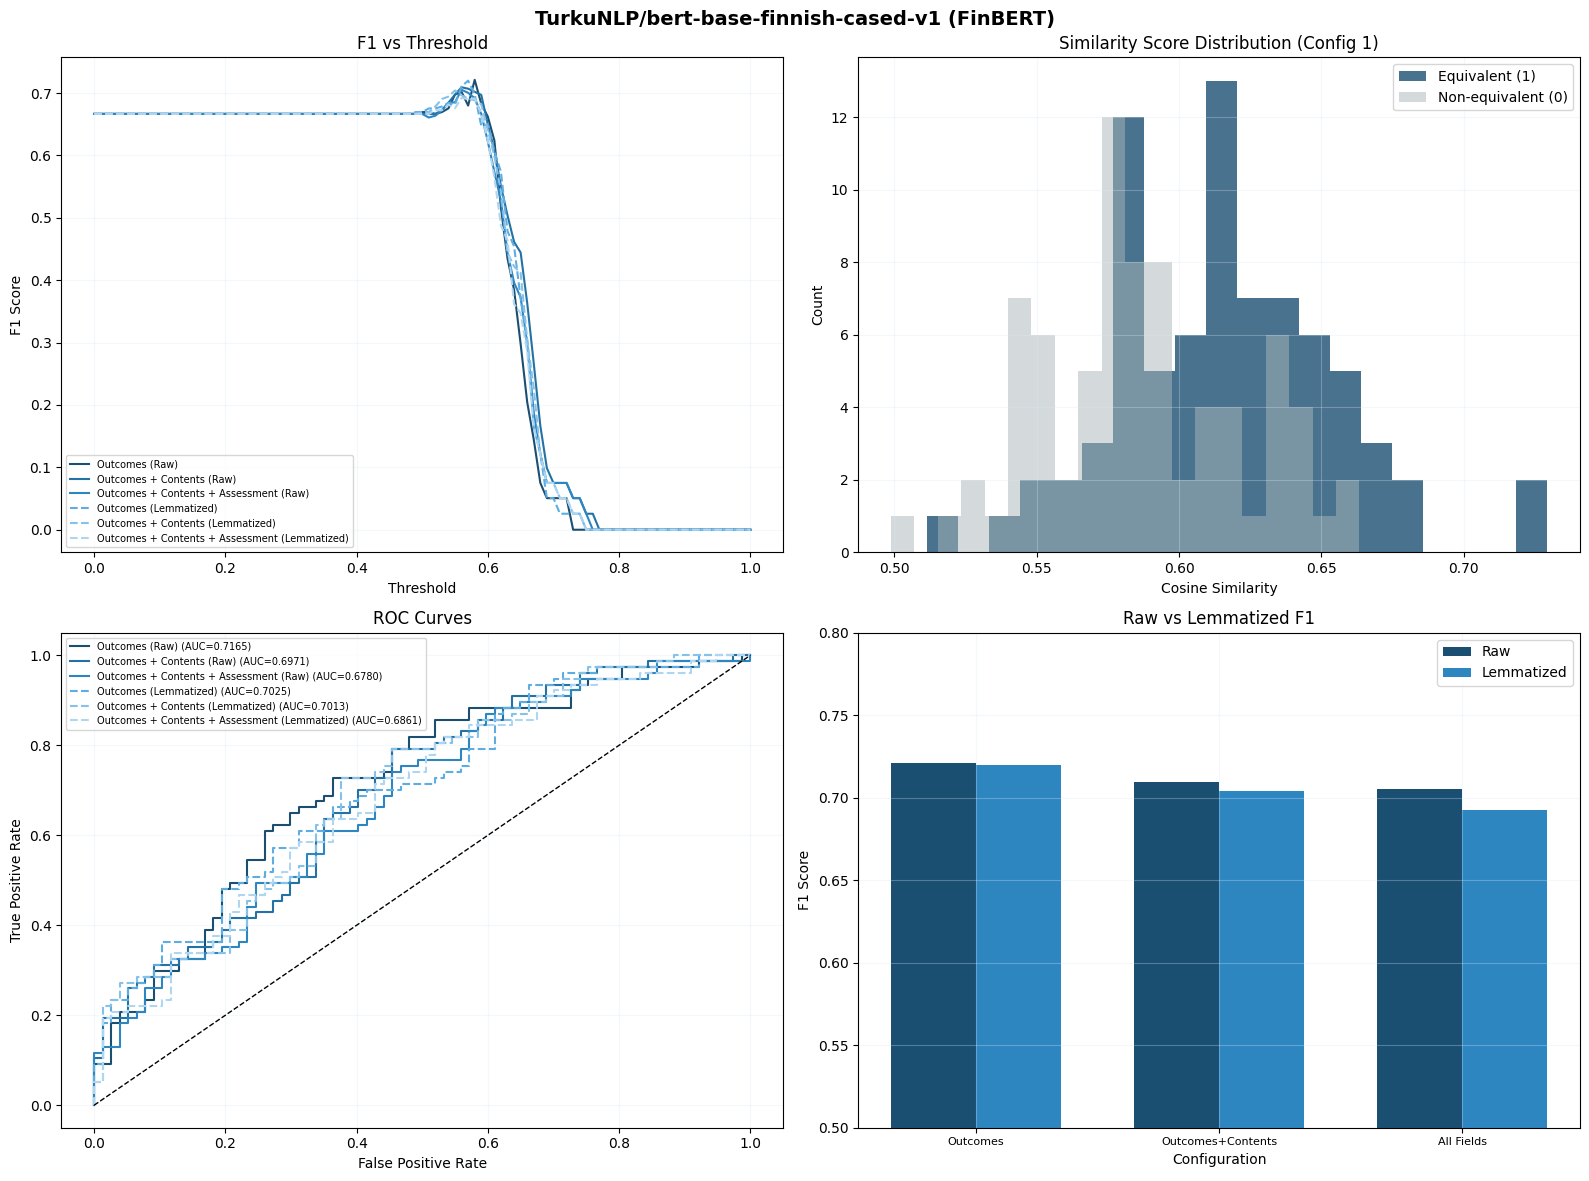

Plot saved: C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final\figures\main\finbert_visualisations.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('TurkuNLP/bert-base-finnish-cased-v1 (FinBERT)', fontsize=14, fontweight='bold')

# Plot 1: F1 vs Threshold
ax1 = axes[0, 0]
for i, config_num in enumerate(configs):
    key = f'finbert_config{config_num}'
    sweep = all_sweep_results[key]
    ax1.plot(sweep['threshold'], sweep['f1'], color=colors[i],
             linestyle=linestyles[i], label=config_names[config_num], linewidth=1.5)
ax1.set_title('F1 vs Threshold')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('F1 Score')
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3, color=GRID_COLOR)

# Plot 2: Similarity Score Distribution (Config 1)
ax2 = axes[0, 1]
key = 'finbert_config1'
scores = all_similarity_scores[key]
pos_scores = scores[labels == 1]
neg_scores = scores[labels == 0]
ax2.hist(pos_scores, bins=20, alpha=0.8, color=POSITIVE, label='Equivalent (1)')
ax2.hist(neg_scores, bins=20, alpha=0.5, color=NEGATIVE, label='Non-equivalent (0)')
ax2.set_title('Similarity Score Distribution (Config 1)')
ax2.set_xlabel('Cosine Similarity')
ax2.set_ylabel('Count')
ax2.legend()
ax2.grid(True, alpha=0.3, color=GRID_COLOR)

# Plot 3: ROC Curves
ax3 = axes[1, 0]
for i, config_num in enumerate(configs):
    key = f'finbert_config{config_num}'
    fpr, tpr = all_fpr_tpr[key]
    auc_val = all_auc[key]
    ax3.plot(fpr, tpr, color=colors[i], linestyle=linestyles[i], linewidth=1.5,
             label=f'{config_names[config_num]} (AUC={auc_val:.4f})')
ax3.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax3.set_title('ROC Curves')
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.legend(fontsize=7)
ax3.grid(True, alpha=0.3, color=GRID_COLOR)

# Plot 4: Raw vs Lemmatized F1
ax4 = axes[1, 1]
raw_f1 = [summary_df[(summary_df['model'] == 'finbert') &
          (summary_df['config'] == config_names[i])]['f1'].values[0] for i in [1, 2, 3]]
lem_f1 = [summary_df[(summary_df['model'] == 'finbert') &
          (summary_df['config'] == config_names[i])]['f1'].values[0] for i in [4, 5, 6]]
x = np.arange(3)
width = 0.35
ax4.bar(x - width/2, raw_f1, width, label='Raw', color=PRIMARY)
ax4.bar(x + width/2, lem_f1, width, label='Lemmatized', color=SECONDARY)
ax4.set_title('Raw vs Lemmatized F1')
ax4.set_xlabel('Configuration')
ax4.set_ylabel('F1 Score')
ax4.set_xticks(x)
ax4.set_xticklabels(['Outcomes', 'Outcomes+Contents', 'All Fields'], fontsize=8)
ax4.legend()
ax4.set_ylim(0.50, 0.80)
ax4.grid(True, alpha=0.3, color=GRID_COLOR)

plt.tight_layout()
plot_path = os.path.join(figures_dir, 'finbert_visualisations.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

FinBERT confirms the monolingual baseline hypothesis with F1 scores between 0.5844 and 0.7213 and AUC values between 0.6780 and 0.7165, all substantially below every multilingual model evaluated in this study. 

The similarity score distribution shows near-complete overlap between equivalent and non-equivalent pairs, both concentrated 
in the narrow range between 0.50 and 0.70, which means the model cannot reliably distinguish the two classes regardless of threshold choice. 

The ROC curves sit close to the diagonal, confirming that the model performs only marginally better than random classification. 

This outcome is expected and interpretable: FinBERT has never been 
exposed to English text or cross-lingual alignment during training, so its embedding space has no mechanism for mapping Finnish and English representations of the same concept to similar vectors. 

The F1 vs threshold curves peak sharply and briefly around 
0.58 before collapsing, reflecting the narrow and unreliable decision boundary available to the model. 

Lemmatization produces no meaningful improvement, which further confirms that the performance limitation is architectural rather than a preprocessing issue. 

FinBERT's inclusion provides a meaningful lower bound that contextualises the gains achieved by the multilingual models.

### Cross-Model Comparison

The following visualisations bring together the results from all five models to directly answer the central research questions. Which model performs best? Which configuration works best across models? How do the models rank against each other in overall discriminative power?

### Best F1 Heatmap Across All Models and Configurations

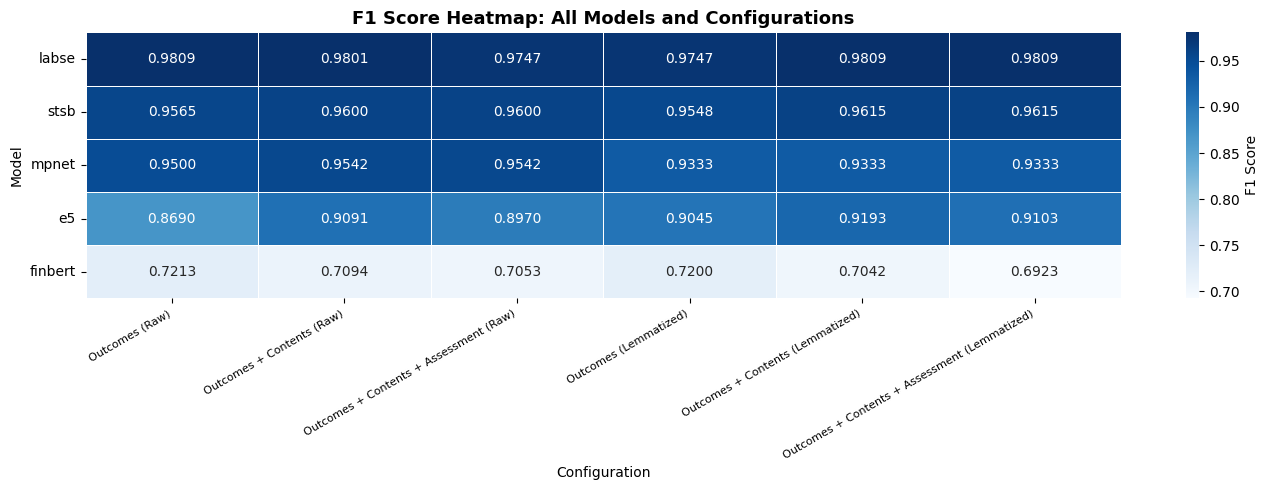

Plot saved: C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final\figures\main\heatmap_f1_all_models.png


In [14]:
# Reshape summary into matrix for heatmap
heatmap_data = summary_df.pivot(index='model', columns='config', values='f1')

# Reorder models from best to worst
model_order = ['labse', 'stsb', 'mpnet', 'e5', 'finbert']
heatmap_data = heatmap_data.reindex(model_order)

# Reorder configs
config_order = list(config_names.values())
heatmap_data = heatmap_data[config_order]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.4f',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'F1 Score'}
)
ax.set_title('F1 Score Heatmap: All Models and Configurations', fontsize=13, fontweight='bold')
ax.set_xlabel('Configuration')
ax.set_ylabel('Model')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plot_path = os.path.join(figures_dir, 'heatmap_f1_all_models.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

The heatmap reveals a clear performance hierarchy across all five models. 

LaBSE occupies the top row with consistently dark green values above 0.97 across every configuration, while FinBERT sits at the bottom in yellow, confirming its inability to perform cross-lingual comparison. 

The three middle models form a distinct middle tier, with stsb consistently outperforming mpnet and e5 trailing both. 

A striking pattern visible across all models except e5 is that raw configurations perform equally well or better than their lemmatized counterparts, suggesting that lemmatization offers no systematic benefit for multilingual sentence embedding models on this task. 

The outcomes-only configuration performs competitively with 
longer configurations across all models, indicating that the learning outcomes field alone carries sufficient semantic information for reliable equivalence detection.

### Best F1 Score per Model

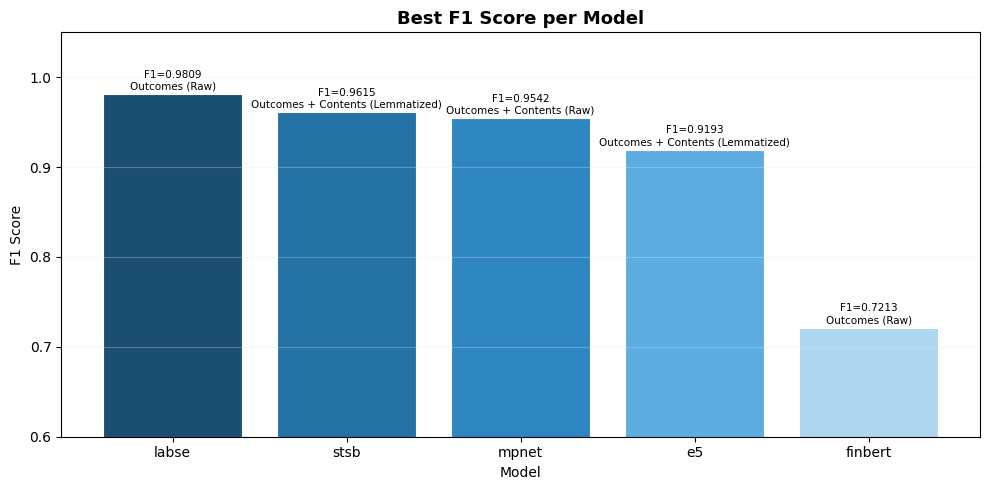

Plot saved: C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final\figures\main\best_f1_per_model.png


In [15]:
best_per_model = summary_df.loc[summary_df.groupby('model')['f1'].idxmax()].reset_index(drop=True)
best_per_model = best_per_model.set_index('model').reindex(model_order).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    best_per_model['model'],
    best_per_model['f1'],
    color=['#1B4F72', '#2471A3', '#2E86C1', '#5DADE2', '#AED6F1'],
    edgecolor='white',
    linewidth=0.8
)

for bar, row in zip(bars, best_per_model.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'F1={row.f1:.4f}\n{row.config}',
        ha='center', va='bottom', fontsize=7.5
    )

ax.set_title('Best F1 Score per Model', fontsize=13, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('F1 Score')
ax.set_ylim(0.60, 1.05)
ax.grid(axis='y', alpha=0.3, color=GRID_COLOR)

plt.tight_layout()
plot_path = os.path.join(figures_dir, 'best_f1_per_model.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

The bar chart confirms the performance hierarchy established in the individual model evaluations. 

LaBSE achieves the highest best F1 of 0.9809 on the outcomes-only raw configuration, followed by stsb at 0.9615, mpnet at 0.9542, and e5 at 0.9193. 

FinBERT sits well below all multilingual models at 0.7213, separated by a gap of over 0.20 F1 points from the next model. 

Notably, the best configuration differs across models: LaBSE and mpnet peak on raw text while stsb and e5 peak on lemmatized 
configurations, reflecting each model's different sensitivity to preprocessing. 

The gap between LaBSE and the second-best model stsb is 0.0194 F1 points, which is meaningful given the near-ceiling performance range, and the consistent AUC advantage of LaBSE across all configurations reinforces that this difference reflects genuine 
discriminative superiority rather than threshold selection variance.

### AUC Score Comparison Across All Models and Configurations

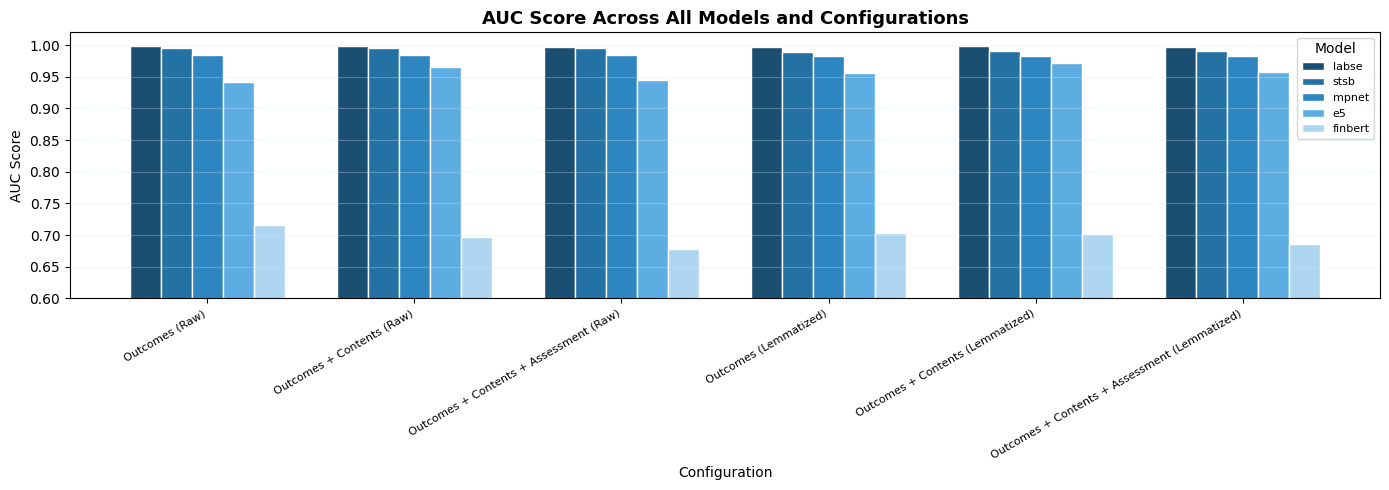

Plot saved: C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final\figures\main\auc_comparison_all_models.png


In [16]:
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(config_names))
width = 0.15
offsets = [-2, -1, 0, 1, 2]
model_colors = ['#1B4F72', '#2471A3', '#2E86C1', '#5DADE2', '#AED6F1']

for i, (model_key, offset, color) in enumerate(zip(model_order, offsets, model_colors)):
    auc_values = [
        summary_df[(summary_df['model'] == model_key) &
                   (summary_df['config'] == config_names[c])]['auc'].values[0]
        for c in range(1, 7)
    ]
    bars = ax.bar(x + offset * width, auc_values, width,
                  label=model_key, color=color, edgecolor='white')

ax.set_title('AUC Score Across All Models and Configurations', fontsize=13, fontweight='bold')
ax.set_xlabel('Configuration')
ax.set_ylabel('AUC Score')
ax.set_xticks(x)
ax.set_xticklabels(list(config_names.values()), rotation=30, ha='right', fontsize=8)
ax.legend(title='Model', fontsize=8)
ax.set_ylim(0.60, 1.02)
ax.grid(axis='y', alpha=0.3, color=GRID_COLOR)

plt.tight_layout()
plot_path = os.path.join(figures_dir, 'auc_comparison_all_models.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

The AUC comparison reinforces the F1 findings with one important addition: the top three models, LaBSE, stsb, and mpnet, all achieve AUC values above 0.98 across every configuration, meaning their ability to rank equivalent pairs above non-equivalent pairs is near-perfect regardless of threshold. 

The e5 model sits visibly lower at around 0.94 to 0.97, confirming that its compressed similarity score range reduces its discriminative power even when threshold selection is removed from the equation.

FinBERT stands clearly apart from all multilingual models with AUC values between 0.68 and 0.72, barely above the 0.50 random baseline. 

The consistency of AUC scores across configurations within each model is also notable: all four multilingual models 
show very little variation across the six configurations, suggesting that the choice of which fields to include matters less than the choice of which model to use.

### Raw vs Lemmatized F1 Comparison Across All Models

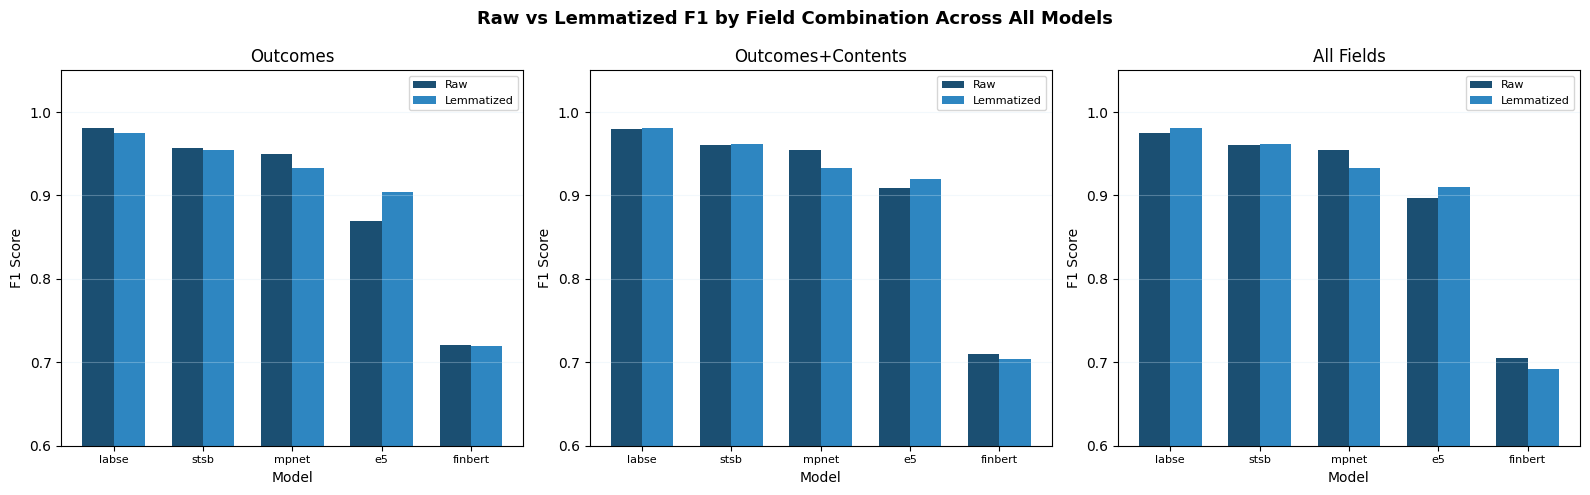

Plot saved: C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final\figures\main\raw_vs_lemmatized_all_models.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Raw vs Lemmatized F1 by Field Combination Across All Models',
             fontsize=13, fontweight='bold')

field_combos = ['Outcomes', 'Outcomes+Contents', 'All Fields']
raw_configs = [1, 2, 3]
lem_configs = [4, 5, 6]

for idx, (ax, raw_c, lem_c, combo) in enumerate(
        zip(axes, raw_configs, lem_configs, field_combos)):

    raw_f1_vals = [
        summary_df[(summary_df['model'] == m) &
                   (summary_df['config'] == config_names[raw_c])]['f1'].values[0]
        for m in model_order
    ]
    lem_f1_vals = [
        summary_df[(summary_df['model'] == m) &
                   (summary_df['config'] == config_names[lem_c])]['f1'].values[0]
        for m in model_order
    ]

    x = np.arange(len(model_order))
    width = 0.35
    ax.bar(x - width/2, raw_f1_vals, width, label='Raw', color=PRIMARY)
    ax.bar(x + width/2, lem_f1_vals, width, label='Lemmatized', color=SECONDARY)
    ax.set_title(combo)
    ax.set_xlabel('Model')
    ax.set_ylabel('F1 Score')
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, fontsize=8)
    ax.legend(fontsize=8)
    ax.set_ylim(0.60, 1.05)
    ax.grid(axis='y', alpha=0.3, color=GRID_COLOR)

plt.tight_layout()
plot_path = os.path.join(figures_dir, 'raw_vs_lemmatized_all_models.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

The three panels tell a consistent story across all field combinations. For LaBSE, stsb, and mpnet, raw and lemmatized bars are nearly identical in height, confirming that lemmatization neither helps nor hurts these models in any meaningful way. 

The e5 model is the clear exception: lemmatized text outperforms raw text across all three field combinations, with the most visible gap appearing in the outcomes-only panel. 

This suggests that e5 benefits from reduced morphological variation in a way that the other multilingual models do not, possibly due to differences in its training data composition or tokenization strategy. 

FinBERT shows no consistent direction, with lemmatization helping marginally in some configurations and hurting in others, which is consistent with a model that lacks the cross-lingual capacity to benefit reliably from any preprocessing strategy. 

The overall pattern strongly supports the conclusion that preprocessing choice is a secondary factor compared to model selection, and that raw text is a sufficient and practical default for the three strongest models in this evaluation.

### Part 2: Stratified 80/20 Validation

The full dataset evaluation in Part 1 selected the optimal threshold and reported performance on the same 154 pairs. 

To assess whether these results hold on unseen data, a stratified 80/20 split is applied here. 

The training portion of 123 pairs is used exclusively for threshold selection, and final metrics are reported only on the held-out test set of 31 pairs. 

The split preserves the 50/50 label balance in both sets. 

If the held-out results are consistent with Part 1, it confirms that the main findings are not an artifact of threshold optimisation on the full dataset.

### Stratified Split and Validation Results

In [18]:
from sklearn.model_selection import train_test_split

# Stratified 80/20 split
train_idx, test_idx = train_test_split(
    np.arange(len(labels)),
    test_size=0.20,
    random_state=42,
    stratify=labels
)

train_labels = labels[train_idx]
test_labels = labels[test_idx]

print(f"Train set: {len(train_idx)} pairs "
      f"(positive: {train_labels.sum()}, negative: {(train_labels==0).sum()})")
print(f"Test set:  {len(test_idx)} pairs "
      f"(positive: {test_labels.sum()}, negative: {(test_labels==0).sum()})")

validation_rows = []

for model_key in model_keys:
    for config_num in configs:
        fi_path = os.path.join(embeddings_dir, f'{model_key}_config{config_num}_fi.npy')
        en_path = os.path.join(embeddings_dir, f'{model_key}_config{config_num}_en.npy')
        fi_emb = np.load(fi_path)
        en_emb = np.load(en_path)

        sim_scores = np.sum(fi_emb * en_emb, axis=1)

        # Select threshold on train set
        train_scores = sim_scores[train_idx]
        best_thresh, best_f1_train = 0, 0
        for t in thresholds:
            preds = (train_scores >= t).astype(int)
            f1 = f1_score(train_labels, preds, zero_division=0)
            if f1 > best_f1_train:
                best_f1_train = f1
                best_thresh = t

        # Evaluate on test set
        test_scores = sim_scores[test_idx]
        test_preds = (test_scores >= best_thresh).astype(int)
        test_precision = precision_score(test_labels, test_preds, zero_division=0)
        test_recall = recall_score(test_labels, test_preds, zero_division=0)
        test_f1 = f1_score(test_labels, test_preds, zero_division=0)
        test_accuracy = accuracy_score(test_labels, test_preds)
        test_auc = roc_auc_score(test_labels, test_scores)

        # Full dataset F1 for comparison
        full_f1 = summary_df[
            (summary_df['model'] == model_key) &
            (summary_df['config'] == config_names[config_num])
        ]['f1'].values[0]

        validation_rows.append({
            'model': model_key,
            'config': config_names[config_num],
            'threshold': best_thresh,
            'test_precision': round(test_precision, 4),
            'test_recall': round(test_recall, 4),
            'test_f1': round(test_f1, 4),
            'test_accuracy': round(test_accuracy, 4),
            'test_auc': round(test_auc, 4),
            'full_f1': round(full_f1, 4),
            'f1_diff': round(test_f1 - full_f1, 4)
        })

validation_df = pd.DataFrame(validation_rows)
validation_path = os.path.join(results_dir, 'validation_8020_results.csv')
validation_df.to_csv(validation_path, index=False)

print(f"\nValidation complete. Results saved.\n")
display(validation_df)

Train set: 123 pairs (positive: 62, negative: 61)
Test set:  31 pairs (positive: 15, negative: 16)

Validation complete. Results saved.



,model,config,threshold,test_precision,test_recall,test_f1,test_accuracy,test_auc,full_f1,f1_diff
0,mpnet,Outcomes (Raw),0.76,0.9375,1.0000,0.9677,0.9677,1.0000,0.9500,0.0177
1,mpnet,Outcomes + Contents (Raw),0.80,1.0000,1.0000,1.0000,1.0000,1.0000,0.9542,0.0458
2,mpnet,Outcomes + Contents + Assessment (Raw),0.80,1.0000,1.0000,1.0000,1.0000,1.0000,0.9542,0.0458
3,mpnet,Outcomes (Lemmatized),0.70,0.8824,1.0000,0.9375,0.9355,0.9958,0.9333,0.0042
4,mpnet,Outcomes + Contents (Lemmatized),0.70,0.8824,1.0000,0.9375,0.9355,0.9958,0.9333,0.0042
5,mpnet,Outcomes + Contents + Assessment (Lemmatized),0.70,0.8824,1.0000,0.9375,0.9355,0.9958,0.9333,0.0042
6,stsb,Outcomes (Raw),0.89,0.9375,1.0000,0.9677,0.9677,0.9958,0.9565,0.0112
7,stsb,Outcomes + Contents (Raw),0.92,1.0000,0.9333,0.9655,0.9677,0.9958,0.9600,0.0055
8,stsb,Outcomes + Contents + Assessment (Raw),0.92,1.0000,0.9333,0.9655,0.9677,0.9958,0.9600,0.0055
9,stsb,Outcomes (Lemmatized),0.89,0.9375,1.0000,0.9677,0.9677,0.9708,0.9548,0.0129


The stratified validation results strongly confirm the main findings from Part 1. 

The performance ranking of LaBSE, stsb, mpnet, e5, and FinBERT is preserved exactly on the held-out test set, and the F1 differences between full dataset and test set results are small throughout, with most values within 0.03 F1 points in either direction. 

LaBSE achieves a perfect test F1 of 1.0000 on three configurations, further reinforcing its dominance. 

The few negative differences, where test F1 falls slightly below full dataset F1, are concentrated in LaBSE's longer configurations and FinBERT, and are small enough to be attributed to the limited size of the 31-pair test set rather than genuine overfitting to the threshold. 

The consistency between Part 1 and Part 2 results across all five models and all six configurations confirms that the threshold selection process did not inflate the main evaluation results, and that the conclusions drawn from the full dataset evaluation are reliable and generalisable within the scope of this dataset.

### Notebook Summary

This notebook evaluated all 30 model-configuration combinations using cosine similarity and threshold-based binary classification.

The full dataset evaluation in Part 1 identified LaBSE as the strongest model, achieving a peak F1 of 0.9809 and AUC of 0.9988 on the outcomes-only raw configuration. 

The performance hierarchy from strongest to weakest was LaBSE, stsb, mpnet, e5, and FinBERT, with FinBERT confirming the monolingual baseline expectation at F1 0.7213. 

Lemmatization produced no consistent benefit for the three strongest models but improved e5 performance across all field combinations. 

The outcomes-only configuration performed competitively with longer configurations across all models, indicating that learning outcomes alone carry sufficient semantic information for reliable quivalence detection. 

The stratified 80/20 validation in Part 2 confirmed that the main findings are robust and not an artifact of threshold selection on the full dataset, with the model ranking preserved exactly on the held-out test set. 

All results and visualisations have been saved to data/results/ and are ready for the extended analysis in Notebook 5.